# Useful methods and attributes of QuantumCircuit and DAGCircuit

Here we give several examples of methods and attributes of QuantumCircuit and DAGCircuit.

In [19]:
from qiskit import QuantumCircuit
import matplotlib.pyplot as plt
from qiskit.dagcircuit import DAGCircuit, DAGOpNode, DAGInNode, DAGOutNode
from qiskit.converters import circuit_to_dag, dag_to_circuit
import networkx as nx

from dac_part import remove_1q_and_consecutive_2q_gates_in_circuit
from collections import defaultdict
from dac_part import *

from ag import qgrid, q20
import time
import os

In [20]:
"""One artificial circuit example"""

qc = QuantumCircuit(10)
for idx in range(5):
   qc.h(idx)
   qc.cx(idx, idx+5)

qc.cx(1, 7)
qc.cx(7,1)
qc.x(8)
qc.cx(9, 4)
qc.x(7)
qc.cx(8, 3)
qc.x(6)
qc.cx(1,5)
qc.cx(0,5)
#qc.draw('mpl')

print(qc.qregs)
#print(qc.qubits)
print(qc.count_ops())
print(qc.num_qubits)
print(qc.depth())
print(qc.width())
print(qc.size())
print(qc.data[15].operation.name)
"""Each item in qc.data is a CircuitInstruction, which has attributes operation and qubits, clbits"""

[QuantumRegister(10, 'q')]
OrderedDict([('cx', 11), ('h', 5), ('x', 3)])
10
6
10
19
cx


'Each item in qc.data is a CircuitInstruction, which has attributes operation and qubits, clbits'

OrderedDict([('u1', 93), ('cx', 92), ('u', 11), ('u3', 2)])
or_6.qasm {'cx': 61} 61
OrderedDict([('u1', 93), ('cx', 92), ('u', 11), ('u3', 2)])
or_6.qasm {'cx': 61} 61
The DAGCircuit has 6 qubits, depth 61, {'cx': 61}
~~~~~~~~~~~~~~~~~~~~~~~~
*node distribution*
~~~~~~~~~~~~~~~~~~~~~~~~
4 [0, 1, 3, 7, 11, 15, 19, 23, 27, 31, 35, 39, 43, 47, 51, 55, 59]
5 [0, 2, 4, 6, 8, 10, 12, 14, 16, 18, 20, 22, 24, 26, 28, 30, 32, 34, 36, 38, 40, 42, 44, 46, 48, 50, 52, 54, 56, 58, 60]
3 [1, 2, 3, 4, 5, 9, 17, 25, 33, 41, 49, 57]
2 [5, 6, 7, 8, 9, 10, 11, 12, 13, 21, 37, 53]
1 [13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 45]
0 [29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60]
*edge distribution*
(4, 5) [0]
(4, 3) [1, 3]
(4, 2) [7, 11]
(4, 1) [15, 19, 23, 27]
(4, 0) [31, 35, 39, 43, 47, 51, 55, 59]
(5, 3) [2, 4]
(5, 2) [6, 8, 10, 12]
(5, 1) [14, 16, 18, 20, 22, 24, 26, 28]
(5, 0) [30, 32, 34, 36, 38

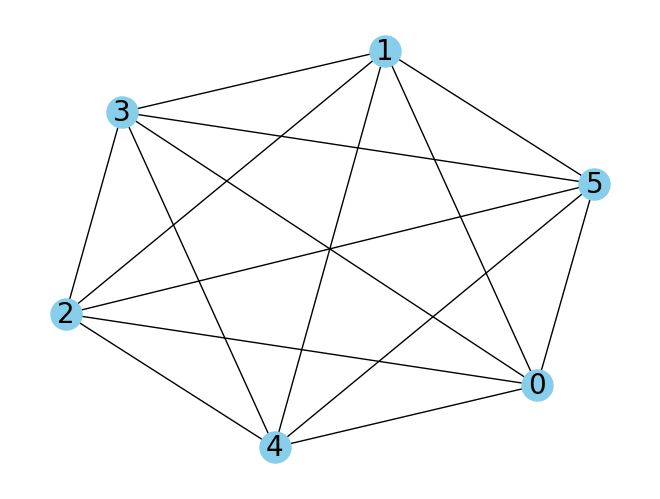

The cutting points are [1, 4, 5, 12, 13, 28, 29, 60]


In [41]:
"""OR circuit"""
path = '../bench/qiskit_circuit_benchmark/' 
filename = 'or_6.qasm'

with open(path+filename, 'r') as file:
    qasm_code = file.read()

qc = QuantumCircuit.from_qasm_str(qasm_code)
print(qc.count_ops())

newcirc = remove_1q_and_consecutive_2q_gates_in_circuit(qc)

dag = circuit_to_dag(newcirc)
print(filename, dag.count_ops(), dag.depth())
print(qc.count_ops())
newcirc = remove_1q_and_consecutive_2q_gates_in_circuit(qc)
dag = circuit_to_dag(newcirc)
print(filename, dag.count_ops(), dag.depth())

g, _, Edge_Layer = graph_profile(newcirc, True)
max_layer_num = dag.depth()
selected_edges = []
cutting_list = all_cutting_points(selected_edges, Edge_Layer, max_layer_num, g)
print(f'The cutting points are {cutting_list}')
#selected_edges = [(3,4)]
#cutting_list = all_cutting_points(selected_edges, Edge_Layer, max_layer_num, g)
#print(f'The cutting points for {selected_edges} are {cutting_list}')

OrderedDict([('u1', 93), ('cx', 92), ('u3', 2)])
and_6.qasm {'cx': 61} 61
The DAGCircuit has 6 qubits, depth 61, {'cx': 61}
~~~~~~~~~~~~~~~~~~~~~~~~
*node distribution*
~~~~~~~~~~~~~~~~~~~~~~~~
4 [0, 1, 3, 7, 11, 15, 19, 23, 27, 31, 35, 39, 43, 47, 51, 55, 59]
5 [0, 2, 4, 6, 8, 10, 12, 14, 16, 18, 20, 22, 24, 26, 28, 30, 32, 34, 36, 38, 40, 42, 44, 46, 48, 50, 52, 54, 56, 58, 60]
3 [1, 2, 3, 4, 5, 9, 17, 25, 33, 41, 49, 57]
2 [5, 6, 7, 8, 9, 10, 11, 12, 13, 21, 37, 53]
1 [13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 45]
0 [29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60]
*edge distribution*
(4, 5) [0]
(4, 3) [1, 3]
(4, 2) [7, 11]
(4, 1) [15, 19, 23, 27]
(4, 0) [31, 35, 39, 43, 47, 51, 55, 59]
(5, 3) [2, 4]
(5, 2) [6, 8, 10, 12]
(5, 1) [14, 16, 18, 20, 22, 24, 26, 28]
(5, 0) [30, 32, 34, 36, 38, 40, 42, 44, 46, 48, 50, 52, 54, 56, 58, 60]
(3, 2) [5, 9]
(3, 1) [17, 25]
(3, 0) [33, 41, 49

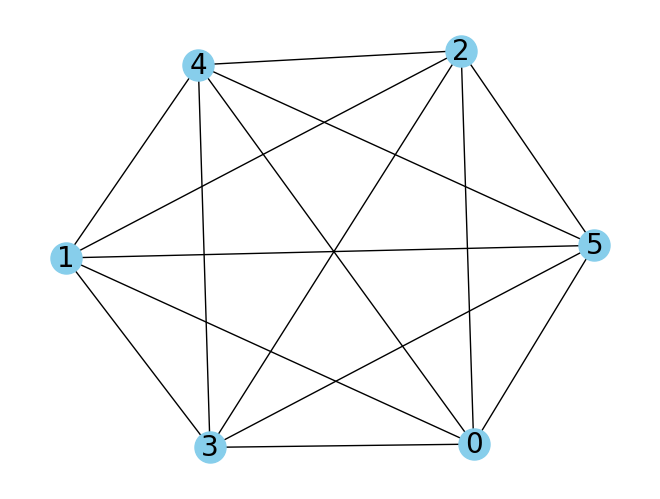

The cutting points are [1, 4, 5, 12, 13, 28, 29, 60]


In [40]:
"""AND circuit
    Something special about this graph
1. node 0 appears after layer 28. this means we can partition the graph into two parts.
2. Some edges like (5,0) appears more often than others. many edges appear only at most twice, 
    which makes the use of bridge gate more attractive.
3. The second part (starting from layer 29) consists of a star graph. 
    Design optimal layout for this type of circuits. 
"""
path = '../bench/qiskit_circuit_benchmark/' 
filename = 'and_6.qasm'

with open(path+filename, 'r') as file:
    qasm_code = file.read()

qc = QuantumCircuit.from_qasm_str(qasm_code)
print(qc.count_ops())
newcirc = remove_1q_and_consecutive_2q_gates_in_circuit(qc)
dag = circuit_to_dag(newcirc)
print(filename, dag.count_ops(), dag.depth())

g, _, Edge_Layer = graph_profile(newcirc, True)
max_layer_num = dag.depth()
selected_edges = []
cutting_list = all_cutting_points(selected_edges, Edge_Layer, max_layer_num, g)
print(f'The cutting points are {cutting_list}')
#selected_edges = [(3,4)]
#cutting_list = all_cutting_points(selected_edges, Edge_Layer, max_layer_num, g)
#print(f'The cutting points for {selected_edges} are {cutting_list}')

OrderedDict([('h', 180), ('cx', 180), ('rx', 180), ('rz', 90), ('u1', 24)])
excitation_preserving_6.qasm {'cx': 45} 21
The DAGCircuit has 6 qubits, depth 21, {'cx': 45}
~~~~~~~~~~~~~~~~~~~~~~~~
*node distribution*
~~~~~~~~~~~~~~~~~~~~~~~~
0 [0, 1, 2, 3, 4, 6, 7, 8, 9, 10, 12, 13, 14, 15, 16]
1 [0, 2, 3, 4, 5, 6, 8, 9, 10, 11, 12, 14, 15, 16, 17]
2 [1, 2, 4, 5, 6, 7, 8, 10, 11, 12, 13, 14, 16, 17, 18]
3 [2, 3, 4, 6, 7, 8, 9, 10, 12, 13, 14, 15, 16, 18, 19]
4 [3, 4, 5, 6, 8, 9, 10, 11, 12, 14, 15, 16, 17, 18, 20]
5 [4, 5, 6, 7, 8, 10, 11, 12, 13, 14, 16, 17, 18, 19, 20]
*edge distribution*
(0, 1) [0, 6, 12]
(0, 2) [1, 7, 13]
(0, 3) [2, 8, 14]
(0, 4) [3, 9, 15]
(0, 5) [4, 10, 16]
(1, 2) [2, 8, 14]
(1, 3) [3, 9, 15]
(1, 4) [4, 10, 16]
(1, 5) [5, 11, 17]
(2, 3) [4, 10, 16]
(2, 4) [5, 11, 17]
(2, 5) [6, 12, 18]
(3, 4) [6, 12, 18]
(3, 5) [7, 13, 19]
(4, 5) [8, 14, 20]


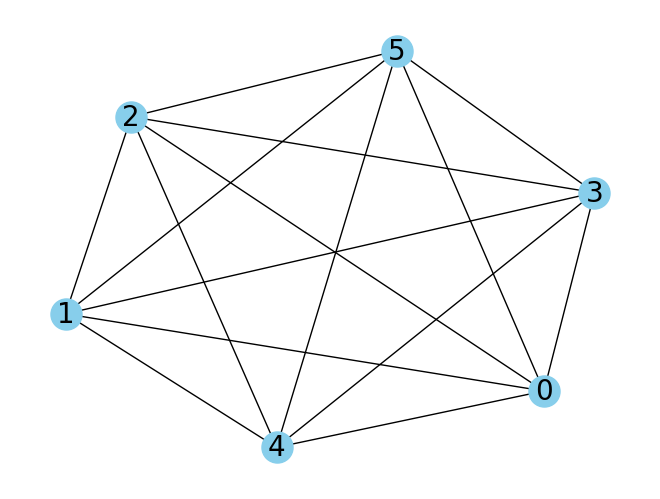

The cutting points are [20]


In [39]:
"""excitation_preserving circuit"""
"""This circuits distributs evenly."""
path = '../bench/qiskit_circuit_benchmark/' 
filename = 'excitation_preserving_6.qasm'

with open(path+filename, 'r') as file:
    qasm_code = file.read()

qc = QuantumCircuit.from_qasm_str(qasm_code)
print(qc.count_ops())
newcirc = remove_1q_and_consecutive_2q_gates_in_circuit(qc)
dag = circuit_to_dag(newcirc)
print(filename, dag.count_ops(), dag.depth())

g, _, Edge_Layer = graph_profile(newcirc, True)
max_layer_num = dag.depth()
selected_edges = []
cutting_list = all_cutting_points(selected_edges, Edge_Layer, max_layer_num, g)
print(f'The cutting points are {cutting_list}')
#selected_edges = [(3,4)]
#cutting_list = all_cutting_points(selected_edges, Edge_Layer, max_layer_num, g)
#print(f'The cutting points for {selected_edges} are {cutting_list}')

OrderedDict([('cx', 36), ('u3', 34), ('u', 23), ('u1', 21), ('u2', 14)])
grover_operator_5.qasm {'cx': 25} 24
The DAGCircuit has 5 qubits, depth 24, {'cx': 25}
~~~~~~~~~~~~~~~~~~~~~~~~
*node distribution*
~~~~~~~~~~~~~~~~~~~~~~~~
3 [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13]
4 [0, 7, 13, 15, 17, 19, 22]
2 [1, 6, 8, 13, 18, 19, 20, 21, 22, 23]
0 [2, 4, 10, 12, 13, 14, 16, 20, 23]
1 [3, 5, 9, 11, 14, 15, 16, 17, 18, 21]
*edge distribution*
(3, 4) [0, 7]
(3, 2) [1, 6, 8, 13]
(3, 0) [2, 4, 10, 12]
(3, 1) [3, 5, 9, 11]
(4, 0) [13]
(4, 1) [15, 17]
(4, 2) [19, 22]
(2, 1) [18, 21]
(2, 0) [20, 23]
(0, 1) [14, 16]


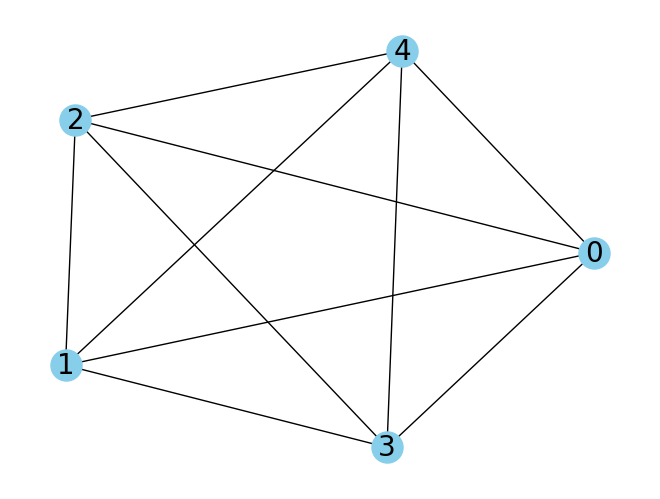

The cutting points are [13, 14, 17, 18, 23]


In [38]:
"""grover_operator circuit"""
path = '../bench/qiskit_circuit_benchmark/' 
filename = 'grover_operator_5.qasm'

with open(path+filename, 'r') as file:
    qasm_code = file.read()

qc = QuantumCircuit.from_qasm_str(qasm_code)
print(qc.count_ops())

newcirc = remove_1q_and_consecutive_2q_gates_in_circuit(qc)
dag = circuit_to_dag(newcirc)
print(filename, dag.count_ops(), dag.depth())

g, _, Edge_Layer = graph_profile(newcirc, True)
max_layer_num = dag.depth()
selected_edges = []
cutting_list = all_cutting_points(selected_edges, Edge_Layer, max_layer_num, g)
print(f'The cutting points are {cutting_list}')
#selected_edges = [(3,4)]
#cutting_list = all_cutting_points(selected_edges, Edge_Layer, max_layer_num, g)
#print(f'The cutting points for {selected_edges} are {cutting_list}')

OrderedDict([('u3', 400), ('cx', 150)])
quantum_volume_10.qasm {'cx': 43} 10
The DAGCircuit has 10 qubits, depth 10, {'cx': 43}
~~~~~~~~~~~~~~~~~~~~~~~~
*node distribution*
~~~~~~~~~~~~~~~~~~~~~~~~
0 [0, 1, 2, 5, 6, 7, 8, 9]
2 [0, 1, 2, 4, 5, 6, 7, 8, 9]
5 [0, 1, 2, 3, 4, 6, 7, 9]
6 [0, 1, 3, 4, 5, 6, 7, 8, 9]
7 [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
1 [0, 1, 2, 4, 5, 6, 7, 8, 9]
8 [0, 1, 3, 4, 5, 6, 8, 9]
4 [0, 1, 2, 3, 4, 5, 6, 8, 9]
9 [0, 1, 2, 3, 4, 6, 7, 8, 9]
3 [0, 1, 2, 5, 6, 7, 9]
*edge distribution*
(0, 2) [0, 8]
(0, 1) [1]
(0, 3) [2]
(0, 8) [5]
(0, 5) [6]
(0, 6) [7]
(0, 9) [9]
(2, 5) [1]
(2, 1) [2, 9]
(2, 8) [4]
(2, 6) [5]
(2, 7) [6]
(2, 9) [7]
(5, 6) [0, 3, 9]
(5, 7) [2]
(5, 9) [4]
(5, 3) [7]
(6, 8) [1, 8]
(6, 7) [4]
(6, 9) [6]
(7, 1) [0, 5, 7]
(7, 9) [1, 8]
(7, 4) [3]
(7, 3) [9]
(1, 4) [4, 8]
(1, 3) [6]
(8, 4) [0, 6, 9]
(8, 9) [3]
(4, 3) [1, 5]
(4, 9) [2]
(9, 3) [0]


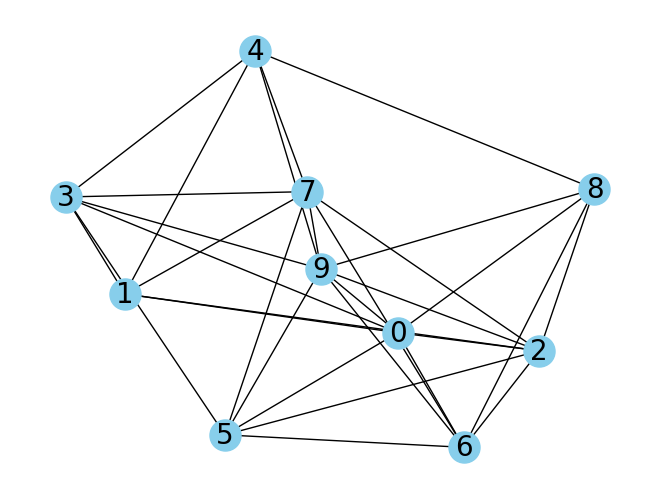

The cutting points are [9]


In [37]:
"""quantum_volume circuit"""
""" each edge appears 1-3 times."""
path = '../bench/qiskit_circuit_benchmark/' 
filename = 'quantum_volume_10.qasm'

with open(path+filename, 'r') as file:
    qasm_code = file.read()

qc = QuantumCircuit.from_qasm_str(qasm_code)
print(qc.count_ops())

newcirc = remove_1q_and_consecutive_2q_gates_in_circuit(qc)

dag = circuit_to_dag(newcirc)
print(filename, dag.count_ops(), dag.depth())

g, _, Edge_Layer = graph_profile(newcirc, True)
max_layer_num = dag.depth()
selected_edges = []
cutting_list = all_cutting_points(selected_edges, Edge_Layer, max_layer_num, g)
print(f'The cutting points are {cutting_list}')
#selected_edges = [(3,4)]
#cutting_list = all_cutting_points(selected_edges, Edge_Layer, max_layer_num, g)
#print(f'The cutting points for {selected_edges} are {cutting_list}')

OrderedDict([('cx', 92), ('p', 62), ('u', 62), ('u3', 6)])
phase_oracle_8.qasm {'cx': 61} 61
The DAGCircuit has 8 qubits, depth 61, {'cx': 61}
~~~~~~~~~~~~~~~~~~~~~~~~
*node distribution*
~~~~~~~~~~~~~~~~~~~~~~~~
5 [0, 1, 3, 7, 11, 15, 19, 23, 27, 31, 35, 39, 43, 47, 51, 55, 59]
6 [0, 2, 4, 6, 8, 10, 12, 14, 16, 18, 20, 22, 24, 26, 28, 30, 32, 34, 36, 38, 40, 42, 44, 46, 48, 50, 52, 54, 56, 58, 60]
4 [1, 2, 3, 4, 5, 9, 17, 25, 33, 41, 49, 57]
3 [5, 6, 7, 8, 9, 10, 11, 12, 13, 21, 37, 53]
2 [13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 45]
1 [29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60]
*edge distribution*
(5, 6) [0]
(5, 4) [1, 3]
(5, 3) [7, 11]
(5, 2) [15, 19, 23, 27]
(5, 1) [31, 35, 39, 43, 47, 51, 55, 59]
(6, 4) [2, 4]
(6, 3) [6, 8, 10, 12]
(6, 2) [14, 16, 18, 20, 22, 24, 26, 28]
(6, 1) [30, 32, 34, 36, 38, 40, 42, 44, 46, 48, 50, 52, 54, 56, 58, 60]
(4, 3) [5, 9]
(4, 2) [17, 25]

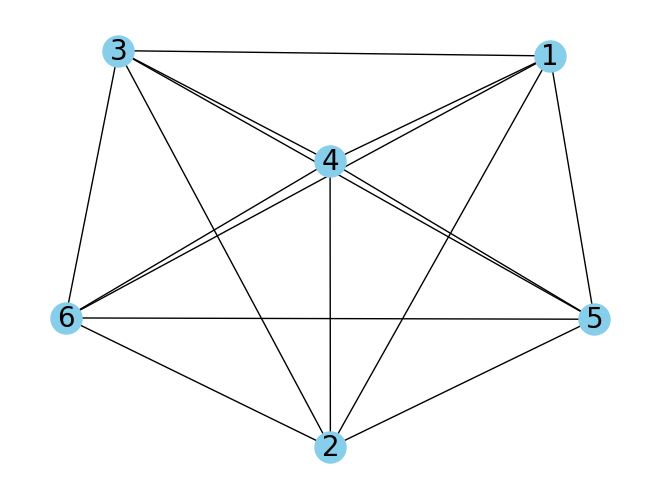

The cutting points are [1, 4, 5, 12, 13, 28, 29, 60]


In [36]:
"""phase_oracle circuit"""
"""This circuit is also stratified: 
    around node (5) | around node (4) | around node (3) | around node (2) | around node (1) """
path = '../bench/qiskit_circuit_benchmark/' 
filename = 'phase_oracle_8.qasm'

with open(path+filename, 'r') as file:
    qasm_code = file.read()

qc = QuantumCircuit.from_qasm_str(qasm_code)
print(qc.count_ops())

newcirc = remove_1q_and_consecutive_2q_gates_in_circuit(qc)

dag = circuit_to_dag(newcirc)
print(filename, dag.count_ops(), dag.depth())

g, _, Edge_Layer = graph_profile(newcirc, True)
max_layer_num = dag.depth()
selected_edges = []
cutting_list = all_cutting_points(selected_edges, Edge_Layer, max_layer_num, g)
print(f'The cutting points are {cutting_list}')
#selected_edges = [(3,4)]
#cutting_list = all_cutting_points(selected_edges, Edge_Layer, max_layer_num, g)
#print(f'The cutting points for {selected_edges} are {cutting_list}')

OrderedDict([('p', 135), ('cx', 105), ('u2', 10)])
qft_10.qasm {'cx': 50} 18
The DAGCircuit has 10 qubits, depth 18, {'cx': 50}
~~~~~~~~~~~~~~~~~~~~~~~~
*node distribution*
~~~~~~~~~~~~~~~~~~~~~~~~
9 [0, 1, 2, 3, 4, 5, 6, 7, 8, 17]
8 [0, 2, 3, 4, 5, 6, 7, 8, 9, 17]
7 [1, 2, 4, 5, 6, 7, 8, 9, 10, 16]
6 [2, 3, 4, 6, 7, 8, 9, 10, 11, 15]
5 [3, 4, 5, 6, 8, 9, 10, 11, 12, 14]
4 [4, 5, 6, 7, 8, 10, 11, 12, 13, 14]
3 [5, 6, 7, 8, 9, 10, 12, 13, 14, 15]
2 [6, 7, 8, 9, 10, 11, 12, 14, 15, 16]
1 [7, 8, 9, 10, 11, 12, 13, 14, 16, 17]
0 [8, 9, 10, 11, 12, 13, 14, 15, 16, 17]
*edge distribution*
(9, 8) [0]
(9, 7) [1]
(9, 6) [2]
(9, 5) [3]
(9, 4) [4]
(9, 3) [5]
(9, 2) [6]
(9, 1) [7]
(9, 0) [8, 17]
(8, 7) [2]
(8, 6) [3]
(8, 5) [4]
(8, 4) [5]
(8, 3) [6]
(8, 2) [7]
(8, 1) [8, 17]
(8, 0) [9]
(7, 6) [4]
(7, 5) [5]
(7, 4) [6]
(7, 3) [7]
(7, 2) [8, 16]
(7, 1) [9]
(7, 0) [10]
(6, 5) [6]
(6, 4) [7]
(6, 3) [8, 15]
(6, 2) [9]
(6, 1) [10]
(6, 0) [11]
(5, 4) [8, 14]
(5, 3) [9]
(5, 2) [10]
(5, 1) [11]
(5, 0) [12]

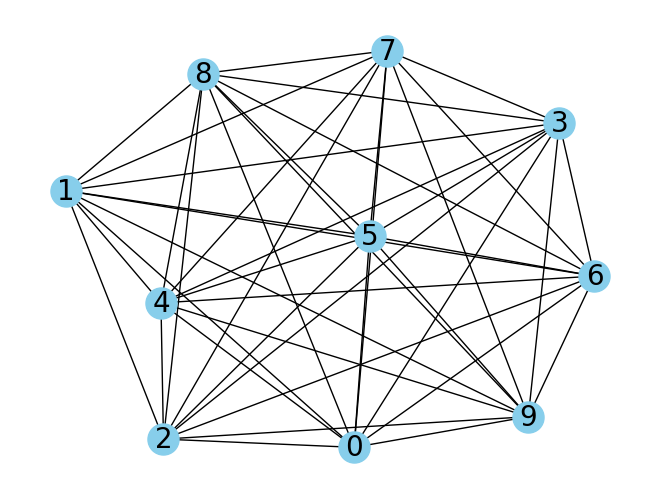

The cutting points are [1, 2, 3, 4, 5, 6, 7, 8, 17]


In [35]:
"""qft circuit"""
path = '../bench/qiskit_circuit_benchmark/' 
filename = 'qft_10.qasm'

with open(path+filename, 'r') as file:
    qasm_code = file.read()

qc = QuantumCircuit.from_qasm_str(qasm_code)
print(qc.count_ops())

newcirc = remove_1q_and_consecutive_2q_gates_in_circuit(qc)

dag = circuit_to_dag(newcirc)
print(filename, dag.count_ops(), dag.depth())

g, _, Edge_Layer = graph_profile(newcirc, True)
max_layer_num = dag.depth()
selected_edges = []
cutting_list = all_cutting_points(selected_edges, Edge_Layer, max_layer_num, g)
print(f'The cutting points are {cutting_list}')
#selected_edges = [(3,4)]
#cutting_list = all_cutting_points(selected_edges, Edge_Layer, max_layer_num, g)
#print(f'The cutting points for {selected_edges} are {cutting_list}')

OrderedDict([('u3', 14), ('cx', 7)])
inner_product_14.qasm {'cx': 7} 1
The DAGCircuit has 14 qubits, depth 1, {'cx': 7}
~~~~~~~~~~~~~~~~~~~~~~~~
*node distribution*
~~~~~~~~~~~~~~~~~~~~~~~~
0 [0]
7 [0]
1 [0]
8 [0]
2 [0]
9 [0]
3 [0]
10 [0]
4 [0]
11 [0]
5 [0]
12 [0]
6 [0]
13 [0]
*edge distribution*
(0, 7) [0]
(1, 8) [0]
(2, 9) [0]
(3, 10) [0]
(4, 11) [0]
(5, 12) [0]
(6, 13) [0]


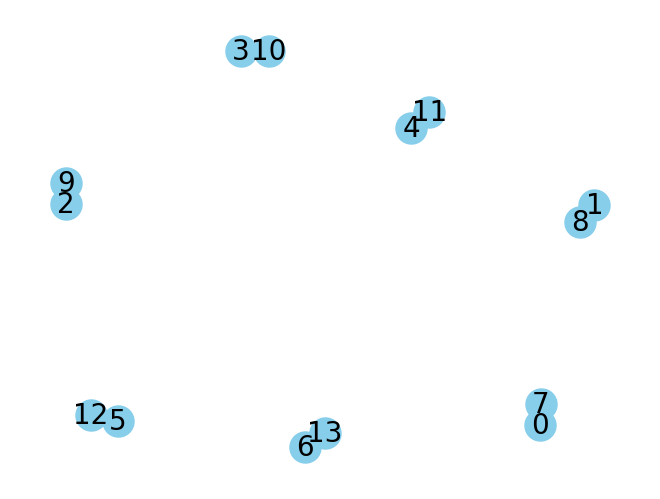

The cutting points are []


In [34]:
"""inner_product circuit (trivial interaction graph)"""
path = '../bench/qiskit_circuit_benchmark/' 
filename = 'inner_product_14.qasm'

with open(path+filename, 'r') as file:
    qasm_code = file.read()

qc = QuantumCircuit.from_qasm_str(qasm_code)
print(qc.count_ops())

newcirc = remove_1q_and_consecutive_2q_gates_in_circuit(qc)

dag = circuit_to_dag(newcirc)
print(filename, dag.count_ops(), dag.depth())

g, _, Edge_Layer = graph_profile(newcirc, True)
max_layer_num = dag.depth()
selected_edges = []
cutting_list = all_cutting_points(selected_edges, Edge_Layer, max_layer_num, g)
print(f'The cutting points are {cutting_list}')
#selected_edges = [(3,4)]
#cutting_list = all_cutting_points(selected_edges, Edge_Layer, max_layer_num, g)
#print(f'The cutting points for {selected_edges} are {cutting_list}')

OrderedDict([('cx', 678), ('u1', 518), ('u', 385), ('u2', 148), ('p', 63), ('u3', 7)])
piecewise_chebyshev_7.qasm {'cx': 310} 286
The DAGCircuit has 7 qubits, depth 286, {'cx': 310}
~~~~~~~~~~~~~~~~~~~~~~~~
*node distribution*
~~~~~~~~~~~~~~~~~~~~~~~~
2 [0, 2, 4, 6, 7, 9, 11, 12, 14, 15, 17, 18, 25, 26, 30, 33, 40, 41, 42, 44, 46, 48, 50, 52, 66, 68, 70, 78, 80, 82, 89, 90, 91, 92, 94, 95, 96, 97, 98, 101, 103, 105, 113, 115, 117, 124, 125, 126, 127, 129, 130, 131, 132, 133, 142, 144, 146, 148, 151, 152, 154, 155, 158, 160, 162, 164, 167, 168, 170, 171, 206, 208, 209, 211, 212, 214, 222, 224, 242, 244, 262, 264, 278, 280, 281]
3 [0, 1, 2, 3, 4, 5, 7, 8, 9, 10, 11, 12, 13, 14, 16, 17, 18, 19, 20, 21, 23, 24, 25, 27, 29, 32, 41, 42, 43, 44, 45, 47, 48, 49, 50, 51, 53, 54, 55, 56, 57, 59, 60, 61, 62, 63, 65, 66, 67, 68, 69, 71, 72, 73, 74, 75, 77, 78, 79, 80, 81, 83, 84, 85, 86, 87, 100, 101, 102, 103, 104, 106, 107, 108, 109, 110, 112, 113, 114, 115, 116, 118, 119, 120, 121, 122, 135, 13

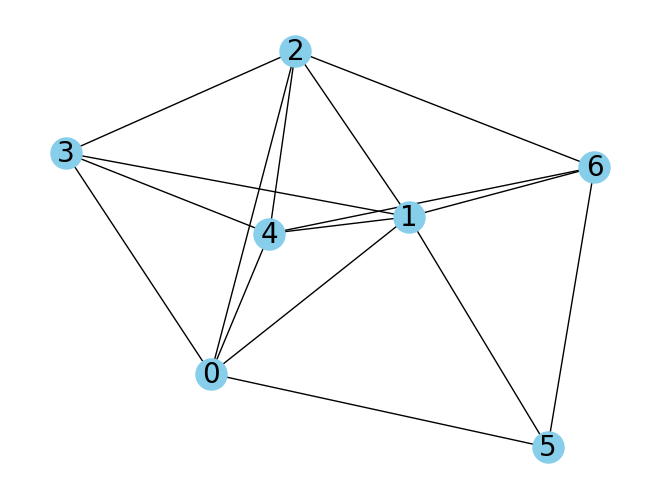

The cutting points are [285]


In [33]:
"""piecewise_chebyshev circuit"""
path = '../bench/qiskit_circuit_benchmark/' 
filename = 'piecewise_chebyshev_7.qasm'

with open(path+filename, 'r') as file:
    qasm_code = file.read()

qc = QuantumCircuit.from_qasm_str(qasm_code)
print(qc.count_ops())

newcirc = remove_1q_and_consecutive_2q_gates_in_circuit(qc)

dag = circuit_to_dag(newcirc)
print(filename, dag.count_ops(), dag.depth())

g, _, Edge_Layer = graph_profile(newcirc, True)
max_layer_num = dag.depth()
selected_edges = []
cutting_list = all_cutting_points(selected_edges, Edge_Layer, max_layer_num, g)
print(f'The cutting points are {cutting_list}')
#selected_edges = [(3,4)]
#cutting_list = all_cutting_points(selected_edges, Edge_Layer, max_layer_num, g)
#print(f'The cutting points for {selected_edges} are {cutting_list}')

OrderedDict([('cx', 54), ('t', 36), ('tdg', 27), ('h', 18), ('u3', 5)])
integer_comparator_12.qasm {'cx': 43} 39
The DAGCircuit has 12 qubits, depth 39, {'cx': 43}
~~~~~~~~~~~~~~~~~~~~~~~~
*node distribution*
~~~~~~~~~~~~~~~~~~~~~~~~
7 [0, 2, 4, 34, 36, 38]
8 [0, 1, 2, 3, 4, 6, 8, 29, 31, 33, 34, 35, 36, 37]
1 [1, 3, 4, 35, 37, 38]
9 [4, 5, 6, 7, 8, 10, 12, 24, 26, 28, 29, 30, 31, 32]
2 [5, 7, 8, 30, 32, 33]
10 [8, 9, 10, 11, 12, 14, 16, 21, 23, 24, 25, 26, 27]
3 [9, 11, 12, 25, 27, 28]
11 [12, 13, 14, 15, 16, 18, 20, 21, 22]
4 [13, 15, 16, 22, 23]
6 [16, 17, 18, 19]
5 [17, 19, 20]
*edge distribution*
(7, 8) [0, 2, 34, 36]
(7, 1) [4, 38]
(8, 1) [1, 3, 35, 37]
(8, 9) [4, 6, 29, 31]
(8, 2) [8, 33]
(9, 2) [5, 7, 30, 32]
(9, 10) [8, 10, 24, 26]
(9, 3) [12, 28]
(10, 3) [9, 11, 25, 27]
(10, 11) [12, 14, 21]
(10, 4) [16, 23]
(11, 4) [13, 15, 22]
(11, 6) [16, 18]
(11, 5) [20]
(6, 5) [17, 19]


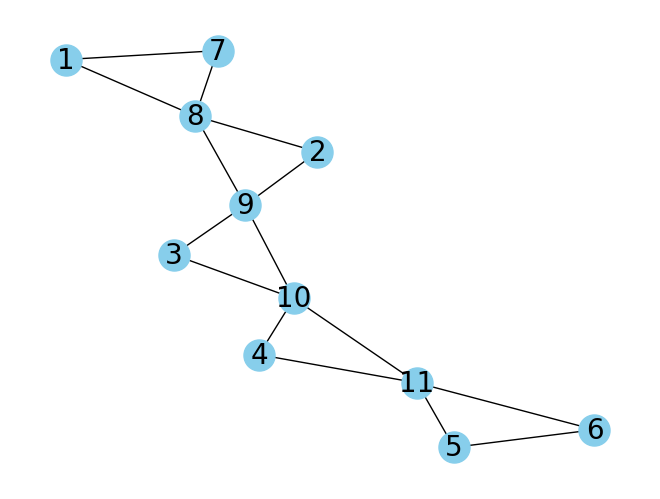

The cutting points are [38]


In [32]:
"""integer_comparator circuit"""
path = '../bench/qiskit_circuit_benchmark/' 
filename = 'integer_comparator_12.qasm'

with open(path+filename, 'r') as file:
    qasm_code = file.read()

qc = QuantumCircuit.from_qasm_str(qasm_code)
print(qc.count_ops())

newcirc = remove_1q_and_consecutive_2q_gates_in_circuit(qc)

dag = circuit_to_dag(newcirc)
print(filename, dag.count_ops(), dag.depth())

g, _, Edge_Layer = graph_profile(newcirc, True)
max_layer_num = dag.depth()
selected_edges = []
cutting_list = all_cutting_points(selected_edges, Edge_Layer, max_layer_num, g)
print(f'The cutting points are {cutting_list}')
#selected_edges = [(3,4)]
#cutting_list = all_cutting_points(selected_edges, Edge_Layer, max_layer_num, g)
#print(f'The cutting points for {selected_edges} are {cutting_list}')

OrderedDict([('u1', 42), ('cx', 38), ('u2', 12), ('u', 4)])
weighted_adder_6.qasm {'cx': 23} 21
The DAGCircuit has 6 qubits, depth 21, {'cx': 23}
~~~~~~~~~~~~~~~~~~~~~~~~
*node distribution*
~~~~~~~~~~~~~~~~~~~~~~~~
2 [0, 2, 4, 9, 11, 12, 14, 15, 18, 20]
4 [0, 1, 2, 3, 4, 6, 8, 9, 10, 12, 13, 14, 15, 17, 18, 19]
0 [1, 3, 4, 5, 7, 8, 10, 11]
3 [4, 5, 6, 7, 15, 16]
1 [13, 15, 16, 17, 19, 20]
*edge distribution*
(2, 4) [0, 2, 9, 12, 14, 18]
(2, 0) [4, 11]
(2, 1) [15, 20]
(4, 0) [1, 3, 8, 10]
(4, 3) [4, 6, 15]
(4, 1) [13, 17, 19]
(0, 3) [5, 7]
(3, 1) [16]


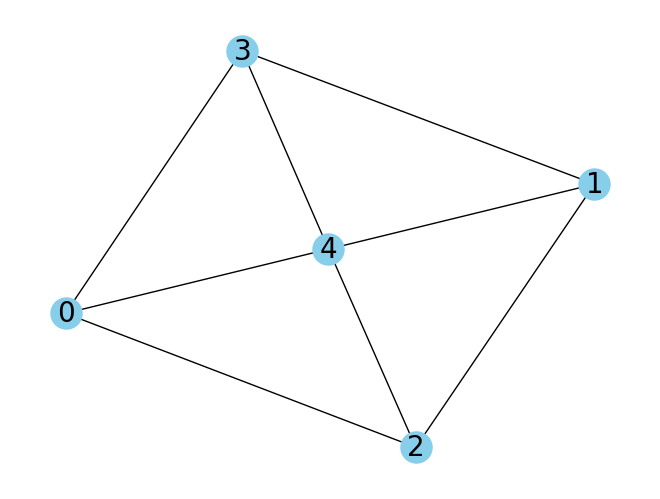

The cutting points are [20]


In [31]:
"""weighted_adder circuit"""
path = '../bench/qiskit_circuit_benchmark/' 
filename = 'weighted_adder_6.qasm'

with open(path+filename, 'r') as file:
    qasm_code = file.read()

qc = QuantumCircuit.from_qasm_str(qasm_code)
print(qc.count_ops())

newcirc = remove_1q_and_consecutive_2q_gates_in_circuit(qc)

dag = circuit_to_dag(newcirc)
print(filename, dag.count_ops(), dag.depth())

g, _, Edge_Layer = graph_profile(newcirc, True)
max_layer_num = dag.depth()
selected_edges = []
cutting_list = all_cutting_points(selected_edges, Edge_Layer, max_layer_num, g)
print(f'The cutting points are {cutting_list}')
#selected_edges = [(3,4)]
#cutting_list = all_cutting_points(selected_edges, Edge_Layer, max_layer_num, g)
#print(f'The cutting points for {selected_edges} are {cutting_list}')

In [14]:
"""quadratic_form circuit"""
path = '../bench/qiskit_circuit_benchmark/' 
filename = 'quadratic_form_6.qasm'

with open(path+filename, 'r') as file:
    qasm_code = file.read()

qc = QuantumCircuit.from_qasm_str(qasm_code)
graph_profile(qc)

(<networkx.classes.graph.Graph at 0x132e47dd0>,
 {0: [0, 1, 2, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18],
  5: [0, 1, 2, 4, 6, 8, 9, 14, 18, 20, 22, 27, 28],
  4: [1, 2, 3, 8, 10, 14, 16, 22, 24, 26, 28],
  1: [1, 2, 3, 4, 5, 7, 8, 9, 10, 12, 19, 20, 21, 22, 23, 24, 25, 26],
  3: [2, 3, 4, 10, 11, 16, 18, 24, 25, 26, 27],
  2: [2, 3, 4, 9, 13, 14, 15, 16, 17, 18, 19, 21, 22, 23, 24, 26]},
 {(0, 5): [0, 6, 8, 14],
  (0, 4): [1, 10, 16],
  (0, 3): [2, 11, 18],
  (0, 1): [5, 7, 9, 12],
  (0, 2): [13, 15, 17],
  (5, 1): [1, 4, 20, 22],
  (5, 2): [2, 9, 18],
  (5, 3): [27],
  (5, 4): [28],
  (4, 1): [2, 8, 24],
  (4, 2): [3, 14, 22],
  (4, 3): [26],
  (1, 3): [3, 10, 25],
  (1, 2): [19, 21, 23, 26],
  (3, 2): [4, 16, 24]})

In [15]:
"""quadratic_form circuit"""
path = '../bench/qiskit_circuit_benchmark/' 
filename = 'quadratic_form_10.qasm'

with open(path+filename, 'r') as file:
    qasm_code = file.read()

qc = QuantumCircuit.from_qasm_str(qasm_code)
graph_profile(qc)

(<networkx.classes.graph.Graph at 0x132f18190>,
 {0: [0,
   1,
   2,
   3,
   4,
   5,
   6,
   9,
   10,
   11,
   12,
   13,
   14,
   15,
   16,
   17,
   18,
   19,
   20,
   21,
   22,
   23,
   24,
   25,
   26,
   27,
   28,
   29,
   30,
   31,
   32,
   33,
   34,
   35,
   36,
   37,
   38],
  9: [0, 1, 2, 8, 10, 12, 13, 26, 38, 40, 42, 59, 60, 61, 62, 63, 64],
  8: [1, 2, 3, 12, 14, 26, 28, 42, 44, 58, 59, 60, 61, 62, 64],
  1: [1,
   2,
   3,
   4,
   5,
   6,
   7,
   8,
   9,
   11,
   12,
   13,
   14,
   15,
   16,
   17,
   18,
   19,
   20,
   21,
   22,
   24,
   39,
   40,
   41,
   42,
   43,
   44,
   45,
   46,
   47,
   48,
   49,
   50,
   51,
   52,
   53,
   54],
  7: [2, 3, 4, 14, 16, 28, 30, 44, 46, 57, 58, 59, 60, 62, 63],
  2: [2,
   3,
   4,
   5,
   6,
   7,
   8,
   13,
   25,
   26,
   27,
   28,
   29,
   30,
   31,
   32,
   33,
   34,
   35,
   36,
   37,
   38,
   39,
   41,
   42,
   43,
   44,
   45,
   46,
   47,
   48,
   49,
   50,
   51,
   

In [16]:
"""hidden_linear circuit"""
path = '../bench/qiskit_circuit_benchmark/' 
filename = 'hidden_linear_6.qasm'

with open(path+filename, 'r') as file:
    qasm_code = file.read()

qc = QuantumCircuit.from_qasm_str(qasm_code)
graph_profile(qc)

"""Each edge appears only once."""

'Each edge appears only once.'

In [17]:
"""iqp circuit"""
path = '../bench/qiskit_circuit_benchmark/' 
filename = 'iqp_6.qasm'

with open(path+filename, 'r') as file:
    qasm_code = file.read()

qc = QuantumCircuit.from_qasm_str(qasm_code)
graph_profile(qc)

"""Here each edge appears only once"""

'Here each edge appears only once'

In [18]:
"""phase_estimation circuit"""
path = '../bench/qiskit_circuit_benchmark/' 
filename = 'phase_estimation_5.qasm'

with open(path+filename, 'r') as file:
    qasm_code = file.read()

qc = QuantumCircuit.from_qasm_str(qasm_code)
graph_profile(qc)

"""Here we can observe that 2 and 3 can be separated at layer 34."""

'Here we can observe that 2 and 3 can be separated at layer 34.'